# Reproduce csv files that are used in the analysis of the H2A manuscript.

This notebook imports the file 'H2A_stats_input_51subs.csv', that contains the discrete variables calculated from the'H2A_reproduce_disc_vars.ipynb' notebook, clean it and output two csv files as follows:
1. 'h2a_comfspeed_43subs.csv' - contains the discrete variables of 43 subjects considering only the comfortable speed trials.
2. 'h2a_allspeeds_43subs.csv' - contains the discrete variables of 43 subjects considering all speed trials.

### Excluded subjects
We excluded 8 subjects from the original dataset of 51 subjects. The reasons for exclusion are as follows:
* 23 and 41: they were excluded in the beginning, presumably, due to odd curves by the notebook;
* 28: one subject that doesn’t address age criteria (Young (18 $\leq$ years $\leq$ 40 ) and Older ($\geq$ 55 years) adults);
* 42 e 51: they were excluded because their comfortable speed is outside the criterion (+/- 10% of the comfortable older speed.
* 2 and 39: they were excluded based on the criteria for cadence outlier identification cadence > 140
* 37: is was removed based on the criteria of H2A_W > 3

The above files are then used as input data for the 'h2a_age_spt_comf_speed.ipynb' and 'speed_age_spt.ipynb' notebooks, respectively, that are publicly available at the following [GitHub repository](https://github.com/BMClab/h2a_age_spt).

In [1]:
# Prep environment
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%load_ext watermark

## Environment setup

In [2]:
import warnings

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore")

pd.options.display.precision = 3
np.set_printoptions(precision=3)


%watermark -u -t -d -m -v --iversions

Last updated: 2026-09-11 15:54:02

Python implementation: CPython
Python version       : 3.14.2
IPython version      : 9.8.0

Compiler    : MSC v.1944 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : Intel64 Family 6 Model 140 Stepping 1, GenuineIntel
CPU cores   : 8
Architecture: 64bit

numpy     : 2.3.5
seaborn   : 0.13.2
matplotlib: 3.10.8
pandas    : 3.0.5



## Supporting functions

In [3]:
# Import data
path2 = Path(r'./../data')
df_all = pd.read_csv(path2 / 'H2A_stats_input_51subs.csv') #initial set with 51 subjects

In [4]:
display(df_all.drop_duplicates(subset='Subject', inplace=False)[
        ['Subject', 'AgeGroup', 'Gender']].groupby(['AgeGroup', 'Gender']).count().T)

AgeGroup Older     Young    
Gender       F   M     F   M
Subject     12  15    10  14

## Data selection
Let's replicate similar conditions of the DeVita and Hortobagyi (2000) study:

Two age categories (Young adults and Older adults).
All subjects walking at a self-selected comfortable speed on a treadmill (for a more reliable control of speed).

In [5]:
df_all0 = df_all.copy(deep=True)

### Remove subjects with oddd curves

In [6]:
# Remove subjects from df_all by odd curves criteria for now
exc_subs_ids = [23, 41]
df_all = df_all[~df_all['Subject'].isin(exc_subs_ids)]

In [7]:
print('Excluded subjects with odd curves:')
df_all0[df_all0['Subject'].isin(exc_subs_ids)].drop_duplicates(subset='Subject', inplace=False)

Excluded subjects with odd curves:


,Subject,AgeGroup,Gender,Age,Height,Mass,BMI,LegLength,SpeedCat,SpeedComf,Speed,StepLength,Cadence,H2A_M,H2A_I,H2A_W
132,23,Young,F,28,1.550,44.90,18.689,0.81,V1,1.52,0.61,0.397,92.664,0.467,0.381,1.438
240,41,Older,F,55,1.495,74.05,33.132,0.75,V1,1.17,0.47,0.349,82.380,0.363,0.243,4.275


In [8]:
# Number of remaining subjects
print('Number of remaining subjects:')
display(df_all.drop_duplicates(subset='Subject', inplace=False)[
        ['Subject', 'AgeGroup']].groupby(['AgeGroup']).count().T)

Number of remaining subjects:


AgeGroup,Older,Young
Subject,26,23


### Remove subjects with age between 40 and 55 years
Subjects in two age categories: Young (18 $\leq$ years $\leq$ 40 ) and Older ($\geq$ 55 years) adults

In [9]:
# Exclude subjects with age between 40 and 55 years
df_all = df_all.drop(index=df_all[(df_all.Age > 40) & (df_all.Age < 55)].index, inplace=False)
df_all.reset_index(drop=True, inplace=True)
# number of subjects in each group
display(df_all.drop_duplicates(subset='Subject', inplace=False)[
        ['Subject', 'AgeGroup', 'Gender']].groupby(['AgeGroup', 'Gender']).count().T)

AgeGroup Older     Young    
Gender       F   M     F   M
Subject     11  14     9  14

In [10]:
print('Excluded subjects with age between 40 and 55 years:')
df_all0[(df_all0.Age > 40) & (df_all0.Age < 55)].drop_duplicates(subset='Subject', inplace=False)

Excluded subjects with age between 40 and 55 years:


,Subject,AgeGroup,Gender,Age,Height,Mass,BMI,LegLength,SpeedCat,SpeedComf,Speed,StepLength,Cadence,H2A_M,H2A_I,H2A_W
162,28,Older,M,50,1.645,71.75,26.515,0.87,V1,1.45,0.58,0.345,101.408,0.491,0.342,1.817


### Include only subjects at a speed similar ($\pm$ 10%) to the comfortable speed of older adults

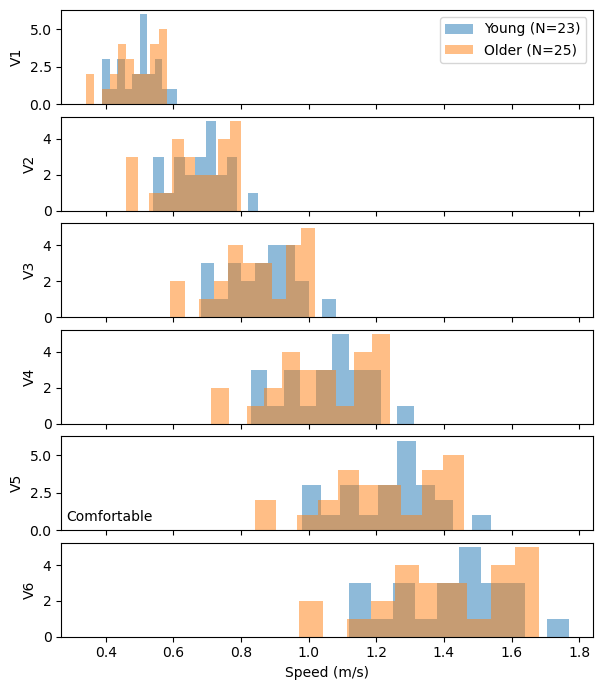

AgeGroup Older                               Young                          \
SpeedCat    V1    V2    V3    V4    V5    V6    V1    V2    V3    V4    V5   
Speed     0.49  0.68  0.86  1.05  1.23  1.41   0.5  0.69  0.88  1.07  1.26   

AgeGroup        
SpeedCat    V6  
Speed     1.45

In [11]:
Ns = df_all.drop_duplicates(subset='Subject')[['Subject', 'AgeGroup']].groupby(['AgeGroup']).count()

ax = df_all[df_all['AgeGroup']=='Young'].hist(column='Speed', by='SpeedCat', layout=(6, 1),
                                      label='Young (N={})'.format(Ns.at['Young', 'Subject']),
                                      alpha=.5, sharex=True, figsize=(6, 7))
df_all[df_all['AgeGroup']=='Older'].hist(column='Speed', by='SpeedCat',
                                 label='Older (N={})'.format(Ns.at['Older', 'Subject']),
                                 alpha=.5, xrot=.1, ax=ax)
ax[0].legend(loc='best')
for a in ax:
    a.set_ylabel(a.title.get_text())
    a.set_title("")
ax[4].text(x=0.01, y=.1, s='Comfortable', horizontalalignment='left', transform=ax[4].transAxes)
ax[5].set_xlabel('Speed (m/s)')
plt.tight_layout(h_pad=0.1)
plt.show()
display(df_all[['Speed', 'AgeGroup', 'SpeedCat']].groupby(['AgeGroup', 'SpeedCat']).median().T)

In [12]:
# limit for maximum variation around the comfortable speed
limit = .1
# Median comfortable speed of the Older group
speed = df_all.loc[(df_all['AgeGroup']=='Older') & (df_all['SpeedCat']=='V5')]['Speed'].median()
# Select trials within +/- 10% of variation of the reference speed
df_all = df_all[(df_all['Speed'] >= (1-limit)*speed) & (df_all['Speed'] <= (1+limit)*speed)]
# Select only one trial per subject
idx = df_all[df_all.duplicated(subset='Subject', keep='first')].index
subjects = [df_all.at[i, 'Subject'] for i in idx]
for s in subjects:
    while df_all[df_all['Subject']==s].shape[0] > 1:
        df_all.drop(index=np.abs(df_all[df_all['Subject']==s]['Speed']-speed).idxmax(), inplace=True)
# drop the SpeedV column
# df.drop(labels='SpeedCat', axis=1, inplace=True)
# Number of remaining subjects
display(df_all.drop_duplicates(subset='Subject', inplace=False)[
        ['Subject', 'AgeGroup']].groupby(['AgeGroup']).count().T)

AgeGroup,Older,Young
Subject,23,23


In [13]:
df_speed = df_all0[(df_all0['Speed'] >= (1-limit)*speed) & (df_all0['Speed'] <= (1+limit)*speed)].drop_duplicates(subset='Subject', inplace=False)
# Find subjects that were excluded due to speed criteria by comparing the list of subjects in df_all0 and df_speed
excluded_subjects = df_all0[~df_all0['Subject'].isin(df_speed['Subject'])].drop_duplicates(subset='Subject', inplace=False)
# Display the rows of df_all0 for the excluded subjects
print('Excluded subjects with speed outside the range of {:.2f} to {:.2f} m/s:'.format((1-limit)*speed, (1+limit)*speed))
df_all0[df_all0['Subject'].isin(excluded_subjects['Subject'])]

Excluded subjects with speed outside the range of 1.11 to 1.35 m/s:


,Subject,AgeGroup,Gender,Age,Height,Mass,BMI,LegLength,SpeedCat,SpeedComf,Speed,StepLength,Cadence,H2A_M,H2A_I,H2A_W
246,42,Older,F,63,1.612,59.85,23.032,0.82,V1,0.89,0.36,0.329,63.492,0.231,0.169,2.445
247,42,Older,F,63,1.612,59.85,23.032,0.82,V2,0.89,0.49,0.398,75.314,0.285,0.192,1.997
248,42,Older,F,63,1.612,59.85,23.032,0.82,V3,0.89,0.63,0.409,91.954,0.388,0.258,2.601
249,42,Older,F,63,1.612,59.85,23.032,0.82,V4,0.89,0.76,0.466,98.361,0.444,0.297,2.319
250,42,Older,F,63,1.612,59.85,23.032,0.82,V5,0.89,0.89,0.498,106.825,0.451,0.299,1.622
251,42,Older,F,63,1.612,59.85,23.032,0.82,V6,0.89,1.03,0.522,118.421,0.551,0.371,1.580
300,51,Older,F,73,1.610,84.85,32.734,0.80,V1,0.84,0.34,0.322,62.446,0.474,0.454,3.455
301,51,Older,F,73,1.610,84.85,32.734,0.80,V2,0.84,0.46,0.390,71.146,0.487,0.472,2.757
302,51,Older,F,73,1.610,84.85,32.734,0.80,V3,0.84,0.59,0.431,81.818,0.499,0.444,2.047
303,51,Older,F,73,1.610,84.85,32.734,0.80,V4,0.84,0.71,0.466,91.603,0.498,0.425,3.070


In [14]:
# Reset index of df_all
df_all.reset_index(drop=True, inplace=True)
df_all

,Subject,AgeGroup,Gender,Age,Height,Mass,BMI,LegLength,SpeedCat,SpeedComf,Speed,StepLength,Cadence,H2A_M,H2A_I,H2A_W
0,1,Young,M,25,1.725,74.30,24.970,0.890,V5,1.21,1.21,0.647,112.853,0.600,0.374,1.592
1,2,Young,F,22,1.668,52.90,19.014,0.865,V5,1.25,1.25,0.523,142.857,0.640,0.240,0.723
2,3,Young,M,33,1.793,75.85,23.594,0.940,V6,0.98,1.12,0.636,105.882,0.520,0.335,1.188
3,4,Young,M,24,1.840,61.05,18.032,0.940,V5,1.30,1.30,0.665,118.033,0.579,0.405,1.156
4,5,Young,M,28,1.709,77.55,26.552,0.860,V5,1.29,1.29,0.648,119.601,0.600,0.375,1.113
5,6,Young,M,25,1.742,83.15,27.401,0.910,V5,1.28,1.28,0.664,115.200,0.552,0.352,0.840
6,7,Young,F,24,1.575,71.75,28.924,0.840,V6,1.10,1.27,0.640,118.812,0.374,0.237,0.899
7,8,Young,M,36,1.825,64.00,19.216,0.970,V4,1.38,1.17,0.643,109.589,0.468,0.355,0.823
8,9,Young,F,25,1.691,61.25,21.420,0.840,V5,1.17,1.17,0.616,113.565,0.495,0.347,1.195
9,10,Young,F,31,1.622,61.70,23.452,0.870,V4,1.37,1.17,0.595,117.455,0.454,0.301,1.023


Export the df_all prior removing outliers to a csv file and use it in the manuscript. This file will be used to address the reviewers' comments regarding the exclusion of outliers from the analysis.

In [15]:
# Export the df_all to a csv file and use it in the manuscript
# df_all.to_csv(path2 / 'h2a_comfspeed_46subs.csv', index=False)

In [16]:
# Remove subjects by speed and age criteria for now
# Display the rows of df_all when the subject is in the list of excluded subjects
exc_subs_ids_2 = [2, 37, 39]
print('Excluded outliers of cadence and H2A_W')
df_excluded = df_all[df_all['Subject'].isin(exc_subs_ids_2)]
df_excluded

Excluded outliers of cadence and H2A_W


,Subject,AgeGroup,Gender,Age,Height,Mass,BMI,LegLength,SpeedCat,SpeedComf,Speed,StepLength,Cadence,H2A_M,H2A_I,H2A_W
1,2,Young,F,22,1.668,52.90,19.014,0.865,V5,1.25,1.25,0.523,142.857,0.640,0.240,0.723
34,37,Older,M,73,1.682,79.65,28.154,0.850,V6,1.11,1.28,0.599,127.660,1.028,0.623,4.349
36,39,Older,M,84,1.555,66.35,27.440,0.790,V6,0.99,1.14,0.441,155.508,0.780,0.481,1.790


In [17]:
# Create a dataframe without the excluded subjects
df_included = df_all[~df_all['Subject'].isin(exc_subs_ids_2)]
# Reset index of df_included
df_included.reset_index(drop=True, inplace=True)
df_included

,Subject,AgeGroup,Gender,Age,Height,Mass,BMI,LegLength,SpeedCat,SpeedComf,Speed,StepLength,Cadence,H2A_M,H2A_I,H2A_W
0,1,Young,M,25,1.725,74.30,24.970,0.890,V5,1.21,1.21,0.647,112.853,0.600,0.374,1.592
1,3,Young,M,33,1.793,75.85,23.594,0.940,V6,0.98,1.12,0.636,105.882,0.520,0.335,1.188
2,4,Young,M,24,1.840,61.05,18.032,0.940,V5,1.30,1.30,0.665,118.033,0.579,0.405,1.156
3,5,Young,M,28,1.709,77.55,26.552,0.860,V5,1.29,1.29,0.648,119.601,0.600,0.375,1.113
4,6,Young,M,25,1.742,83.15,27.401,0.910,V5,1.28,1.28,0.664,115.200,0.552,0.352,0.840
5,7,Young,F,24,1.575,71.75,28.924,0.840,V6,1.10,1.27,0.640,118.812,0.374,0.237,0.899
6,8,Young,M,36,1.825,64.00,19.216,0.970,V4,1.38,1.17,0.643,109.589,0.468,0.355,0.823
7,9,Young,F,25,1.691,61.25,21.420,0.840,V5,1.17,1.17,0.616,113.565,0.495,0.347,1.195
8,10,Young,F,31,1.622,61.70,23.452,0.870,V4,1.37,1.17,0.595,117.455,0.454,0.301,1.023
9,11,Young,M,32,1.920,77.55,21.037,0.980,V5,1.31,1.31,0.703,111.455,0.462,0.295,0.614


In [18]:
display(df_included[
        ['Subject', 'AgeGroup', 'Gender']].groupby(['AgeGroup', 'Gender']).count().T)

AgeGroup Older     Young    
Gender       F   M     F   M
Subject      9  12     8  14

In [19]:
# Export the df_included to a csv file and use it in the manuscript
# df_included.to_csv(path2 / 'h2a_comfspeed_43subs.csv', index=False)

## Create 'h2a_allspeeds_43subs.csv'
Export a file containing all speeds of the 43 subjects that were included in the analysis. This file will be used as the input data for the 'speed_age_spt.ipynb' notebook, which is publicly available at the following [GitHub repository](https://github.com/Reginaldo/H2A_WBDS).

In [20]:
exc_subs = [23,41,2,37,39,28,42,51] # Excluded subjects
# Drop the excluded subjects from df_all0 to create a new dataframe df_included2
df_included2 = df_all0[~df_all0['Subject'].isin(exc_subs)]

In [21]:
# Export df_included2 to a csv file and use it in the manuscript
# df_included2.to_csv(path2 / 'h2a_allspeeds_43subs.csv', index=False)